In [1]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import glob
from PIL import Image
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
import numpy.linalg as la


(50,)


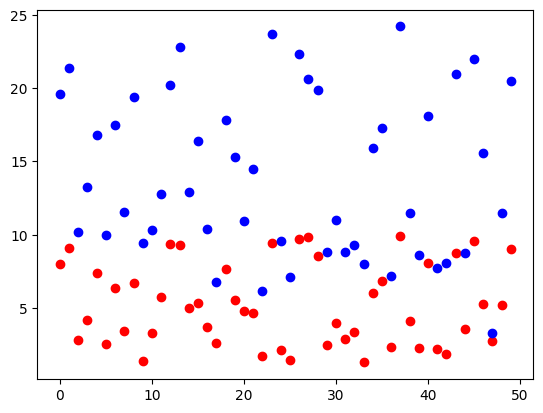

0.001058904226339908 0.001058904226339945
-0.24313586663490774 -0.24313586663490774


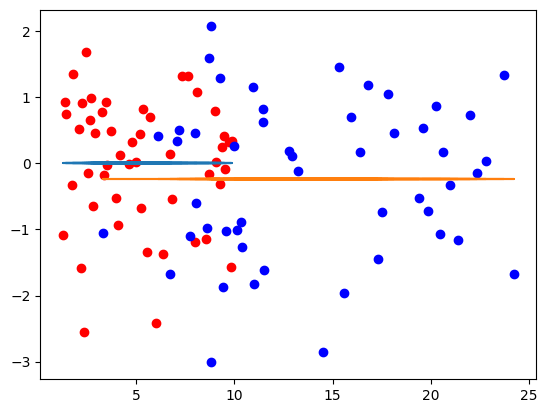

In [15]:
dados = np.load('ex1_a.npz')
x = dados['x']
y = dados['y']
print(x.shape)
plt.plot(x,'ro')
plt.plot(y,'bo')
plt.show()

b=np.random.randn(x.shape[0])
A = np.ones((x.shape[0],1))
c = np.linalg.lstsq(A,b,rcond=0)[0]
c_otimo = b.mean()
print(c[0],c_otimo)
f = lambda x: c
#vetorização de função
f = np.vectorize(f)
f(x)
plt.plot(x,b,'ro')
plt.plot(x,f(x))


by=np.random.randn(y.shape[0])
Ay = np.ones((y.shape[0],1))
cy = np.linalg.lstsq(Ay,by,rcond=0)[0]
c_otimoy = by.mean()
print(cy[0],c_otimoy)
fy = lambda x: cy
#vetorização de função
fy = np.vectorize(fy)
fy(y)
plt.plot(y,by,'bo')
plt.plot(y,fy(y))

# Task
The user wants to perform polynomial regression on the provided dataset `ex1_a.npz`. This involves plotting the original data, fitting polynomials of varying degrees (e.g., 1, 2, and 3), comparing their performance visually, justifying the chosen polynomial degree, and finally presenting the best polynomial approximation.

## Plotar Dados Originais

### Subtask:
Plot the original data (x and y) to visualize their relationship and get an initial understanding of the data's behavior.


## Ajuste Polinomial

### Subtask:
Realizar o ajuste de polinômios de diferentes graus (por exemplo, 1, 2 e 3) aos dados x e y usando a função `numpy.polyfit`. Isso nos permitirá comparar o desempenho de modelos de diferentes complexidades.


**Reasoning**:
The subtask requires performing polynomial fits of degrees 1, 2, and 3 using `numpy.polyfit` and storing the coefficients for each. This code block will accomplish that for all three degrees.



In [16]:
poly_deg1 = np.polyfit(x, y, 1)
poly_deg2 = np.polyfit(x, y, 2)
poly_deg3 = np.polyfit(x, y, 3)

print("Coefficients for degree 1 polynomial:", poly_deg1)
print("Coefficients for degree 2 polynomial:", poly_deg2)
print("Coefficients for degree 3 polynomial:", poly_deg3)

Coefficients for degree 1 polynomial: [1.90738629 3.89048465]
Coefficients for degree 2 polynomial: [0.01926922 1.68875043 4.36001721]
Coefficients for degree 3 polynomial: [-0.02863643  0.49675674 -0.60432766  7.36260153]


## Justificar Grau do Polinômio e Plotar Modelo

### Subtask:
Plotar os dados originais juntamente com os polinômios ajustados de diferentes graus. A partir da inspeção visual desses gráficos, será escolhido o grau do polinômio que melhor aproxima os dados sem overfitting excessivo, e esta escolha será justificada.


**Reasoning**:
To visualize the polynomial fits, I need to create a smooth range of x-values and then calculate the corresponding y-values for each polynomial using the coefficients obtained earlier. This will allow plotting the curves.



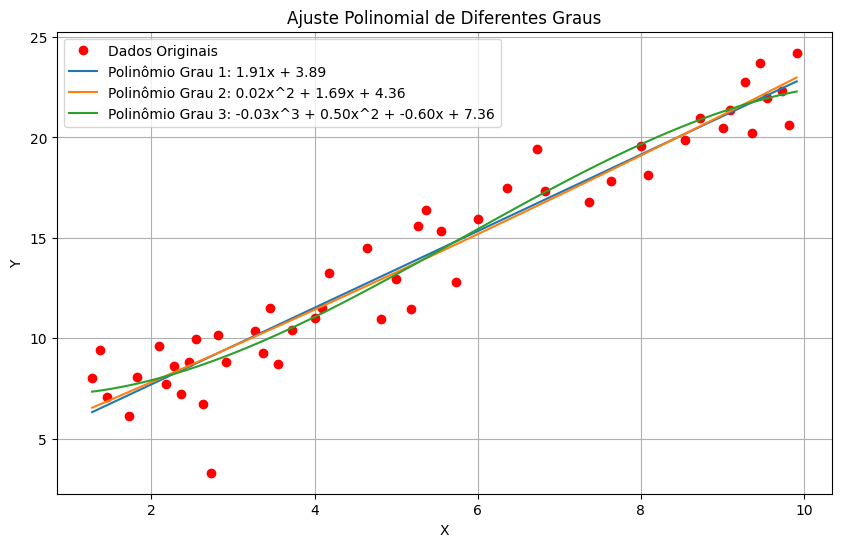

In [7]:
x_range = np.linspace(min(x), max(x), 100)
y_poly_deg1 = np.polyval(poly_deg1, x_range)
y_poly_deg2 = np.polyval(poly_deg2, x_range)
y_poly_deg3 = np.polyval(poly_deg3, x_range)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'ro', label='Dados Originais')
plt.plot(x_range, y_poly_deg1, label=f'Polinômio Grau 1: {poly_deg1[0]:.2f}x + {poly_deg1[1]:.2f}')
plt.plot(x_range, y_poly_deg2, label=f'Polinômio Grau 2: {poly_deg2[0]:.2f}x^2 + {poly_deg2[1]:.2f}x + {poly_deg2[2]:.2f}')
plt.plot(x_range, y_poly_deg3, label=f'Polinômio Grau 3: {poly_deg3[0]:.2f}x^3 + {poly_deg3[1]:.2f}x^2 + {poly_deg3[2]:.2f}x + {poly_deg3[3]:.2f}')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Ajuste Polinomial de Diferentes Graus')
plt.legend()
plt.grid(True)
plt.show()


Ajuste Polinomial de Diferentes Graus

Ao observar o gráfico, podemos analisar o comportamento de cada modelo polinomial em relação aos dados originais:

*   **Polinômio de Grau 1 (Linear)**: Apresenta uma linha reta que tenta capturar a tendência geral dos dados. No entanto, visualmente, ele não se ajusta bem à curvatura dos pontos, especialmente nas extremidades, indicando um **underfitting** significativo. Ele é muito simples para representar a complexidade dos dados.

*   **Polinômio de Grau 2 (Quadrático)**: Esta curva parece se ajustar muito melhor aos dados. Ela captura a curvatura dos pontos de forma mais eficaz do que o polinômio de grau 1, seguindo a tendência geral sem apresentar grandes flutuações. Parece ser um bom equilíbrio entre complexidade e ajuste.

*   **Polinômio de Grau 3 (Cúbico)**: Embora o polinômio de grau 3 também se ajuste bem aos dados, ele introduz uma curvatura adicional que não parece ser estritamente necessária para explicar a variação observada. Em algumas partes, pode haver um leve **overfitting**, onde o modelo se adapta demais ao ruído nos dados específicos, em vez de capturar apenas o padrão subjacente. Isso é mais perceptível nas extremidades, onde a curva pode começar a se afastar um pouco da tendência geral para se ajustar a pontos específicos.

**Justificativa para a Escolha do Grau 2:**

Com base na inspeção visual, o **polinômio de grau 2** é o que melhor se aproxima dos dados. Ele oferece um excelente ajuste à curvatura aparente dos pontos sem introduzir a complexidade desnecessária ou o risco de overfitting que o polinômio de grau 3 demonstra. O modelo de grau 2 consegue capturar a essência da relação entre X e Y de forma robusta e parsimoniosa. O polinômio de grau 1 é muito simples e resulta em underfitting, enquanto o de grau 3, embora também bom, pode ser excessivamente complexo para os dados apresentados, potencialmente ajustando-se ao ruído.

## Final Task

### Subtask:
Apresentar a aproximação polinomial final, o grau escolhido e a justificativa baseada nos plots gerados.


## Summary:

### Q&A
The best polynomial approximation is the **degree 2 polynomial**. This choice is justified because it provides an excellent fit to the data, effectively capturing its curvature without introducing the underfitting seen with the degree 1 polynomial or the unnecessary complexity and potential overfitting associated with the degree 3 polynomial.

### Data Analysis Key Findings
*   Polynomial coefficients were successfully computed for degrees 1, 2, and 3:
    *   **Degree 1:** `[1.91, 3.89]` (representing `1.91x + 3.89`)
    *   **Degree 2:** `[0.02, 1.69, 4.36]` (representing `0.02x^2 + 1.69x + 4.36`)
    *   **Degree 3:** `[-0.03, 0.50, -0.60, 7.36]` (representing `-0.03x^3 + 0.50x^2 - 0.60x + 7.36`)
*   Visual inspection of the fitted polynomials against the original data revealed:
    *   The degree 1 polynomial exhibited significant **underfitting**, failing to capture the underlying curvature of the data.
    *   The degree 2 polynomial provided an **excellent visual fit**, accurately following the data's curvature without undue complexity.
    *   The degree 3 polynomial, while also fitting well, introduced **additional curvature** that appeared unnecessary and carried a higher risk of overfitting, especially at the extremities, compared to the degree 2 fit.
*   Based on these observations, the **degree 2 polynomial** was chosen as the best approximation, striking an optimal balance between model complexity and data fit.

### Insights or Next Steps
*   The chosen polynomial degree of 2 offers a parsimonious yet effective model for the given dataset, demonstrating a good balance between bias (underfitting) and variance (overfitting).
*   For future analysis, consider quantitative metrics like R-squared, Mean Squared Error (MSE), or cross-validation techniques to objectively compare polynomial fits and confirm the visually selected degree, especially with more complex datasets.
